
# Support Vector Machines (SVM)

## What is SVM?

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for:

* Classification
* Regression
* Non-linear classification (using kernels)

Unlike Logistic Regression, which focuses on predicting probabilities, SVM focuses on finding the **best decision boundary** that separates different classes.

---

# Main Intuition

Suppose there are many possible lines that can separate two classes.

Which one should we choose?

SVM says:

> Choose the line that leaves the maximum possible distance from both classes.

This distance is called the **Margin**.

A larger margin generally leads to:

* Better generalization
* Better robustness
* Less sensitivity to noise

---

# Hyperplane

The decision boundary in SVM is called a **Hyperplane**.

Its equation is:

$$
w^Tx + b = 0
$$

where:

* $w$ → Weight vector (normal to the hyperplane)
* $b$ → Bias (intercept)

---

# Classification Rule

For a new point:

### Positive Class

$$
w^Tx + b \geq 0
$$

### Negative Class

$$
w^Tx + b < 0
$$

---

# Support Vectors

The points closest to the decision boundary are called:

## Support Vectors

These points completely determine the position of the hyperplane.

Interestingly:

> Moving other data points does not change the hyperplane.

But moving the support vectors changes the entire decision boundary.

---

# Margin

The margin is the distance between:

* Positive support plane
* Negative support plane

The support planes are:

### Positive Support Plane

$$
w^Tx+b=1
$$

### Negative Support Plane

$$
w^Tx+b=-1
$$

---

# Why Maximize the Margin?

Suppose new unseen data arrives.

If the margin is very small:

* Small changes can lead to misclassification.

If the margin is large:

* The classifier becomes more robust.
* Better generalization.

Therefore, SVM aims to:

> Maximize the margin.

---

# Mathematical Constraint

Assign labels:

$$
y_i \in {-1,+1}
$$

Then every training point must satisfy:

$$
y_i(w^Tx_i+b)\geq1
$$

This guarantees that every point is correctly classified and lies outside the margin.

---

# Margin Width

The distance between the two support planes is:

$$
\text{Margin}
=
\frac{2}{||w||}
$$
---

# Objective Function

To maximize:

$$
\frac{2}{||w||}
$$

we can equivalently minimize:

$$
||w||
$$

For mathematical convenience, we minimize:

$$
\boxed{
\frac12 ||w||^2
}
$$

---

# Hard Margin SVM Optimization Problem

Objective:

$$
\text{Minimize}
\qquad
\frac12 ||w||^2
$$

Subject to:

$$
y_i(w^Tx_i+b)\geq1
$$

---

# Limitation of Hard Margin SVM

Hard Margin SVM assumes:

> Data must be perfectly linearly separable.

Real-world datasets rarely satisfy this condition.

Problems:

* Noise
* Outliers
* Overlapping classes

In such cases:

Hard Margin SVM fails.

---

# Soft Margin SVM

To handle non-perfectly separable data, we introduce:

## Slack Variables

$$
\xi_i \geq 0
$$

These variables allow:

* Points inside the margin
* Misclassified points

---

# New Constraint

The hard constraint:

$$
y_i(w^Tx_i+b)\geq1
$$

becomes:

$$
y_i(w^Tx_i+b)\geq1-\xi_i
$$

---

# Interpretation of Slack Variables

### Case 1

$$
\xi_i=0
$$

Point is correctly classified and lies outside the margin.

---

### Case 2

$$
0<\xi_i\leq1
$$

Point lies inside the margin but is still correctly classified.

---

### Case 3

$$
\xi_i>1
$$

Point is misclassified.

---

# Soft Margin Objective Function

Now we have two goals:

1. Maximize the margin.
2. Minimize classification errors.

Therefore:

$$
\boxed{
\text{Minimize}
\qquad
\frac12 ||w||^2
+
C\sum_{i=1}^{n}\xi_i
}
$$

Subject to:

$$
y_i(w^Tx_i+b)\geq1-\xi_i
$$

$$
\xi_i\geq0
$$

---

# Role of Hyperparameter C

The hyperparameter:

$$
C
$$

controls the trade-off between:

* Large margin
* Classification errors

---

## Large C

Large penalty on errors.

Model tries to classify every point correctly.

Result:

* Smaller margin
* Low Bias
* High Variance
* Overfitting risk

---

## Small C

Small penalty on errors.

Model allows some misclassifications.

Result:

* Larger margin
* High Bias
* Low Variance
* Better generalization

---

# Connection with Regularization

Soft Margin SVM behaves very similarly to:

## L2 Regularization (Ridge Regression)

because:

$$
\frac12 ||w||^2
$$

penalizes large weights.

You can think of:

$$
C \propto \frac1\lambda
$$

where:

* Large C → Less regularization.
* Small C → More regularization.

---

# Advantages of SVM

* Works well on high-dimensional data.
* Very robust due to maximum margin.
* Effective for both linear and non-linear problems.
* Less prone to overfitting.

---

# Limitations of SVM

* Computationally expensive on large datasets.
* Sensitive to hyperparameter tuning.
* Hard to interpret.
* Choosing the correct kernel can be difficult.

---

# Main Intuition

SVM asks one simple question:

> Among all possible separating hyperplanes, which one leaves the maximum distance from both classes?

The answer is:

> The hyperplane with the maximum margin.

This idea of maximizing the margin is what makes SVM one of the most powerful classification algorithms in Machine Learning.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

# Forget the code and Focus on Intution 

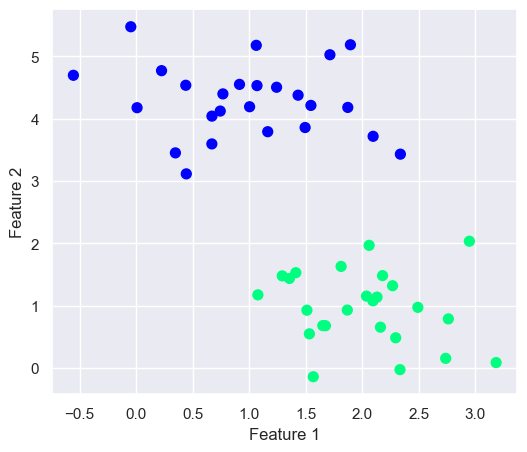

In [4]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=50,      # total data points
    centers=2,         # number of clusters/classes
    random_state=0,    # reproducible results
    cluster_std=0.60   # spread of each cluster
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [5]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

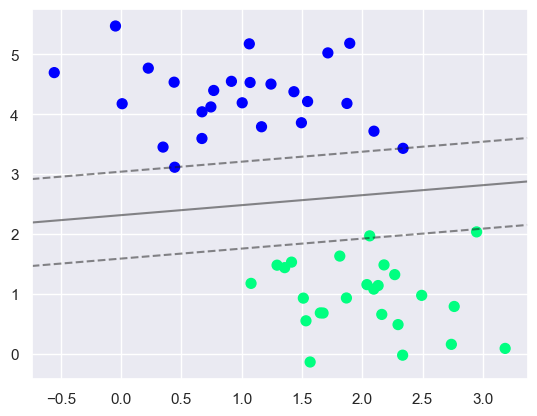

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

## The importance of Support Vectors

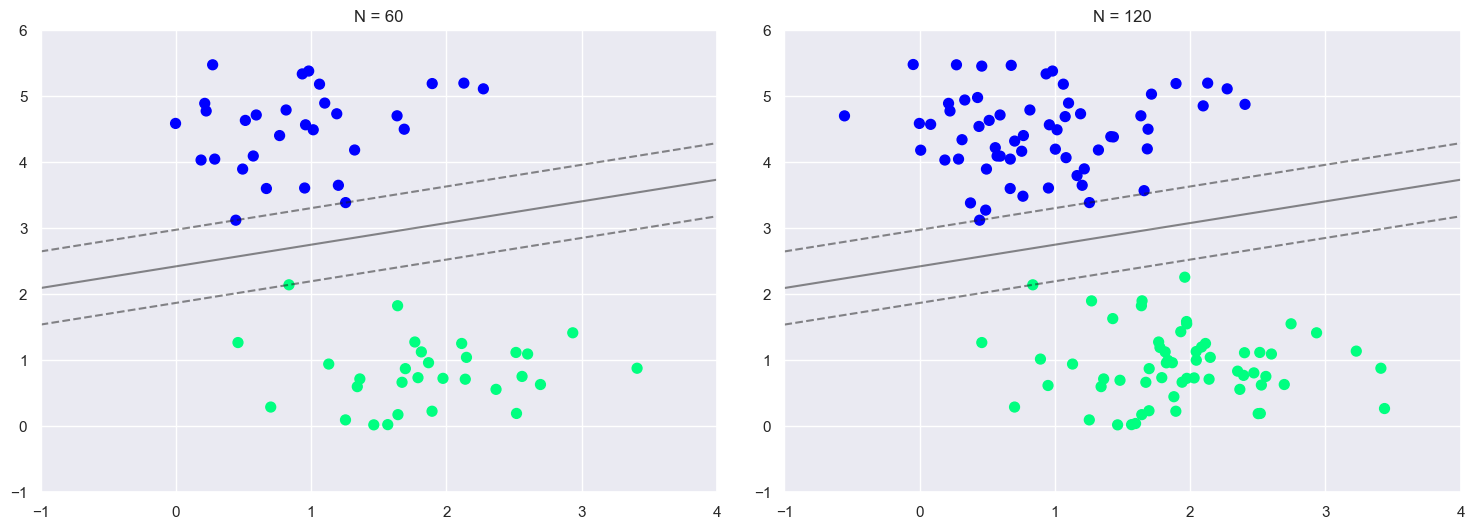

In [8]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

## Working with Almost Linearly Separable Dataset

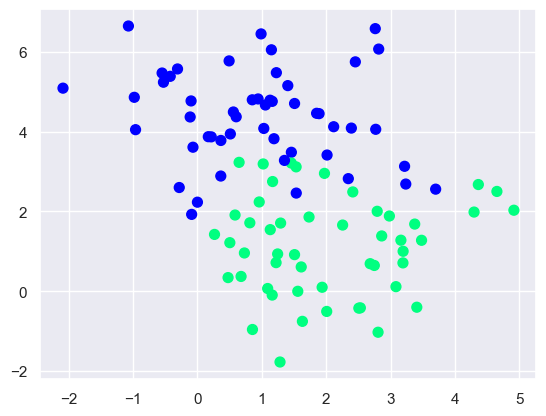

In [9]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

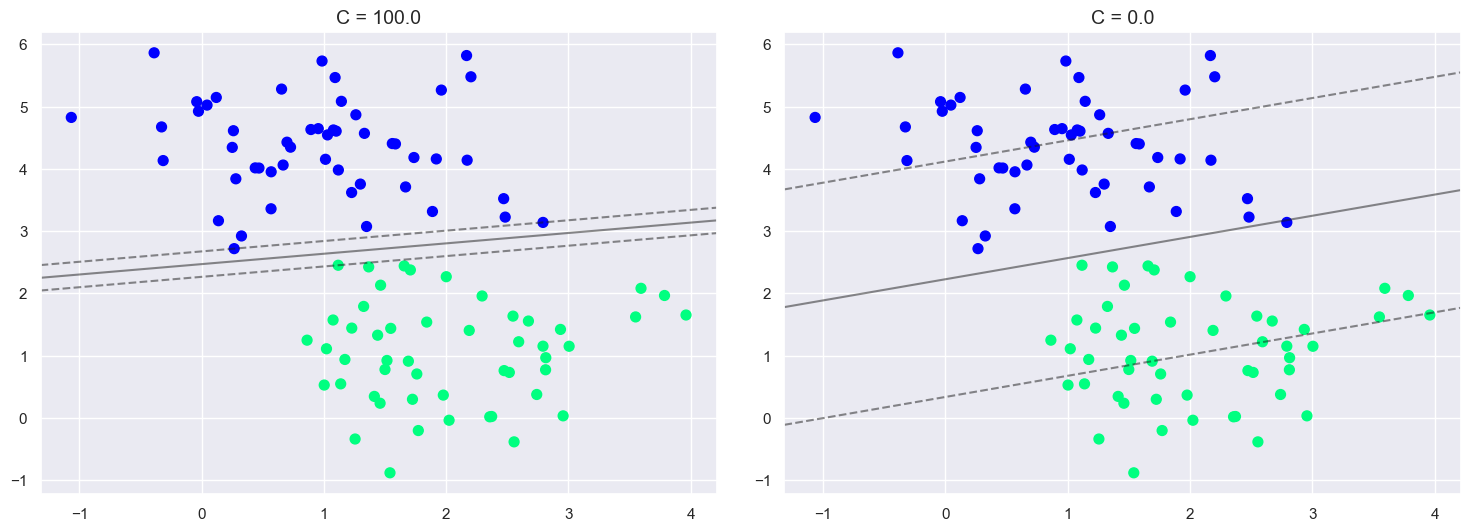

In [10]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)